In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


In [2]:
df=pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

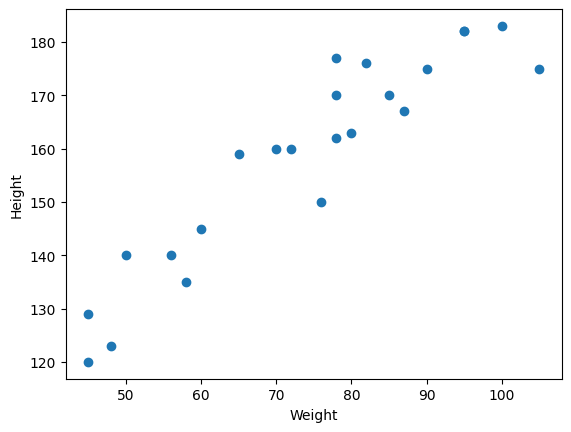

In [3]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [4]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [5]:
x=df[['Weight']]
y=df[['Height']]


In [6]:
from sklearn.model_selection import train_test_split

In [7]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
# standardize the data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [9]:
print(x_train)

[[ 1.73689094]
 [-0.92026952]
 [ 1.4542143 ]
 [ 0.21043706]
 [-1.48562281]
 [ 1.17153765]
 [-1.6552288 ]
 [-0.80719886]
 [-0.24184557]
 [ 0.0973664 ]
 [-1.37255215]
 [-1.03334018]
 [-0.12877492]
 [ 0.88886101]
 [ 0.43657837]
 [ 0.60618436]
 [ 0.71925502]
 [ 0.32350772]]


In [10]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)


LinearRegression()

In [11]:
print('coefficients:',model.coef_)
print('intercept:',model.intercept_)

coefficients: [[17.03440872]]
intercept: [157.5]


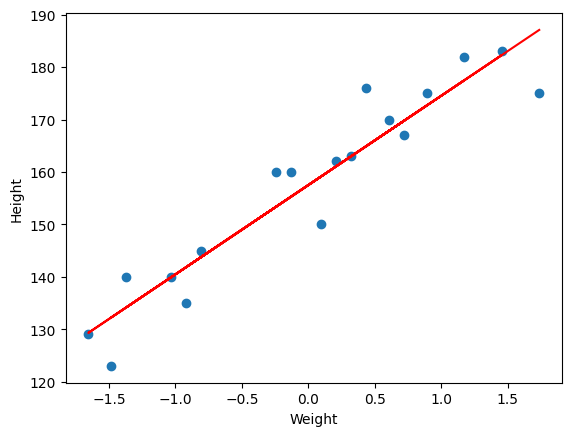

In [12]:
plt.scatter(x_train,y_train)
plt.plot(x_train,model.predict(x_train),color='red')
plt.xlabel("Weight")
plt.ylabel("Height")
plt.show()

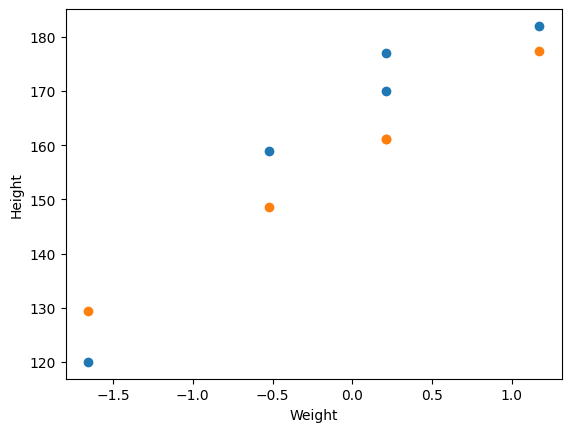

In [13]:
# testing the model
y_pred=model.predict(x_test)
plt.scatter(x_test,y_test)
plt.scatter(x_test,y_pred)
plt.xlabel("Weight")
plt.ylabel("Height")
plt.show()

In [14]:
# preformance metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,root_mean_squared_error
print('Mean Absolute Error:',mean_absolute_error(y_test,y_pred))
print('Mean Squared Error:',mean_squared_error(y_test,y_pred))
print('Root Mean Squared Error:',np.sqrt(mean_squared_error(y_test,y_pred)))
print('R2 Score:',r2_score(y_test,y_pred))


Mean Absolute Error: 9.822657814519232
Mean Squared Error: 109.77592599051664
Root Mean Squared Error: 10.477400726827081
R2 Score: 0.776986986042344


In [18]:
model.predict(scaler.transform([[80]]))

c:\Users\natkh\Downloads\assignment_solution\venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[163.01076266]])

#### ols linear regression

In [19]:
import statsmodels.api as sm


In [20]:
model=sm.OLS(y_train,x_train).fit()
prediction=model.predict(x_test)
print(prediction)

[  3.58467086   3.58467086 -28.1958439   19.95645118  -8.93492586]


In [23]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.047
Method:                 Least Squares   F-statistic:                             0.1986
Date:                Sat, 15 Mar 2025   Prob (F-statistic):                       0.661
Time:                        11:32:35   Log-Likelihood:                         -116.62
No. Observations:                  18   AIC:                                      235.2
Df Residuals:                      17   BIC:                                      236.1
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\natkh\Downloads\assignment_solution\venv\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)
